## Subset selection methods

*Adapted from Introduction to Statistical Learning with Python* [(link)](https://github.com/intro-stat-learning/ISLP_labs/blob/main/Ch06-varselect-lab.ipynb)

Here we implement methods that reduce the number of parameters in a model by restricting the model to a subset of the input variables.

### Forward Selection
 
We will  apply the forward-selection approach to the  `Hitters` data.  We wish to predict a baseball player’s `Salary` on the basis of various statistics associated with performance in the previous year.


In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.pipeline import Pipeline
from matplotlib.ticker import MaxNLocator
import warnings
warnings.simplefilter("ignore")

In [189]:
Hitters = load_data('Hitters')
Hitters = Hitters.dropna(); # remove rows with one or more missing values
Hitters.shape

(263, 20)

In [190]:
X = MS(Hitters.columns.drop('Salary')).fit_transform(Hitters)
Y = np.array(Hitters['Salary'])
sigma2 = OLS(Y,X).fit().scale


In [191]:
def Cp(sigma2, estimator, X, Y):
    "Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return (RSS + 2 * p * sigma2) / n 

In [192]:
def RSS(estimator, X, Y):
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return RSS

In [193]:
# Forward stepwise

n = len(Y)
predictors = X.columns.drop('intercept')

selected = ['intercept']
remaining = predictors.copy()
variable_path = []
cp_path = []
rss_path = []

# include intercept-only model
X_current = X[selected]
fit0 = OLS(Y, X_current).fit()
cp0 = Cp(sigma2, fit0, X_current, Y)
rss0 = RSS(fit0, X_current, Y)
variable_path.append({"predictors": selected.copy()})
cp_path.append(cp0)
rss_path.append(rss0)

# build up models
for j in range(len(predictors)):
    best = None
    for cand in remaining:
        trial = selected + [cand]
        fit = OLS(Y, X[trial]).fit()
        cp = Cp(sigma2, fit, X[trial], Y)
        rss = RSS(fit, X[trial], Y)
        if (best is None) or (cp < best["cp"]):
            best = {"cand": cand, "cp": cp, "rss": rss}

    selected.append(best["cand"])
    remaining = remaining.drop(best["cand"])

    p = len(selected)
    variable_path.append({"predictors": selected.copy()})
    cp_path.append(best['cp'])
    rss_path.append(best['rss'])

In [194]:
np.argmin(cp_path)

np.int64(10)

In [195]:
variable_path[np.argmin(cp_path)]

{'predictors': ['intercept',
  'CRBI',
  'Hits',
  'PutOuts',
  'Division[W]',
  'AtBat',
  'Walks',
  'CWalks',
  'CRuns',
  'CAtBat',
  'Assists']}

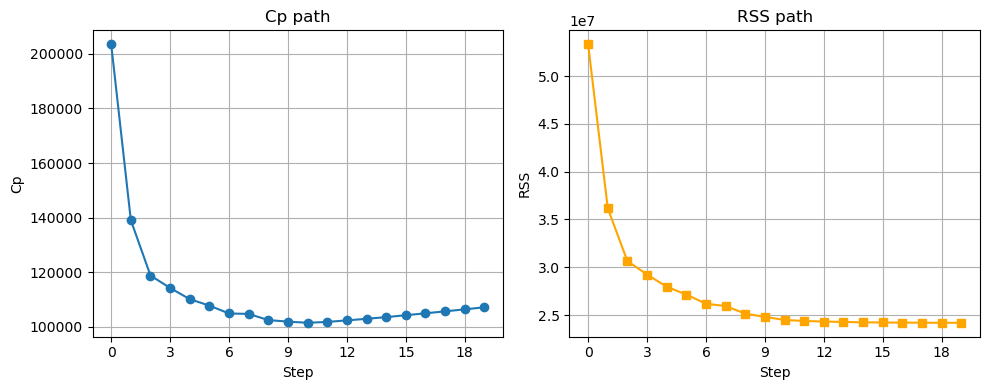

In [196]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Cp on left
axs[0].plot(cp_path, marker='o')
axs[0].set_xlabel('Step')
axs[0].set_ylabel('Cp')
axs[0].set_title('Cp path')
axs[0].grid(True)
axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# RSS on right
axs[1].plot(rss_path, marker='s', color='orange')
axs[1].set_xlabel('Step')
axs[1].set_ylabel('RSS')
axs[1].set_title('RSS path')
axs[1].grid(True)
axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### Backward stepwise

In [197]:
n = len(Y)
predictors = X.columns.drop('intercept')

selected = predictors.copy()
variable_path = []
cp_path = []
rss_path = []

fit = OLS(Y, X).fit()
cp = Cp(sigma2, fit, X, Y)
rss = RSS(fit, X, Y)
variable_path.append({"predictors": selected.copy()})
cp_path.append(cp)
rss_path.append(rss)

for j in range(len(predictors)):
    best = None
    for cand in selected:
        trial = [p for p in selected if p != cand]
        trial_all = ['intercept'] + trial
        fit = OLS(Y, X[trial_all]).fit()
        cp = Cp(sigma2, fit, X[trial_all], Y)
        rss = RSS(fit, X[trial_all], Y)
        if (best is None) or (cp < best["cp"]):
            best = {"rm": cand, "cp": cp, "rss": rss, "trial": trial}

    selected = best['trial']

    variable_path.append({"predictors": selected.copy()})
    cp_path.append(best['cp'])
    rss_path.append(best['rss'])

In [198]:
variable_path[np.argmin(cp_path)]

{'predictors': ['AtBat',
  'Hits',
  'Walks',
  'CAtBat',
  'CRuns',
  'CRBI',
  'CWalks',
  'Division[W]',
  'PutOuts',
  'Assists']}

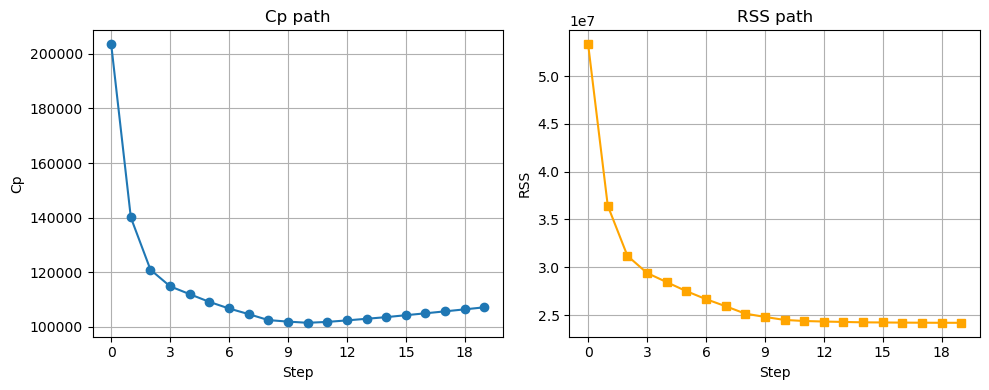

In [199]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Cp on left
axs[0].plot(np.arange(0, p)[::-1], cp_path, marker='o')
axs[0].set_xlabel('Step')
axs[0].set_ylabel('Cp')
axs[0].set_title('Cp path')
axs[0].grid(True)
axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# RSS on right
axs[1].plot(np.arange(0, p)[::-1],rss_path, marker='s', color='orange')
axs[1].set_xlabel('Step')
axs[1].set_ylabel('RSS')
axs[1].set_title('RSS path')
axs[1].grid(True)
axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

We get the same answer, whether we do forward or backward stepwise!

### The Lasso

We now fit the Lasso. We use K-fold cross-validation to select the regularization parameter, $\lambda$.

In [200]:
K=5
scaler = StandardScaler(with_mean=True, with_std=True)

In [201]:
dat = MS(Hitters.columns.drop('Salary')).fit_transform(Hitters)
dat = dat.drop('intercept', axis=1) # remove intercept - it is added automatically
X = np.asarray(dat)

We use Pipeline to pipe together the standardization step and the lassoCV step.

In [202]:
lassoCV = skl.ElasticNetCV(alphas=100, # search over 100 different values of lambda
                           l1_ratio=1,
                           cv=K)
pipeCV = Pipeline(steps=[('scaler', scaler),
                         ('lasso', lassoCV)])
pipeCV.fit(X, Y)
tuned_lasso = pipeCV.named_steps['lasso']

`lassoCV` runs cross-validation for the following candidate $\lambda$ values (determined automatically):

In [203]:
tuned_lasso.alphas_

array([255.28209651, 238.0769376 , 222.03134882, 207.06717903,
       193.11154419, 180.09647243, 167.95857295, 156.63872727,
       146.08180131, 136.23637682, 127.05450099, 118.49145286,
       110.50552551, 103.05782294,  96.1120706 ,  89.63443871,
        83.59337754,  77.95946367,  72.70525674,  67.80516577,
        63.23532454,  58.9734753 ,  54.99886045,  51.29212133,
        47.83520402,  44.61127137,  41.60462098,  38.80060878,
        36.18557761,  33.74679078,  31.47237003,  29.35123763,
        27.37306245,  25.52820965,  23.80769376,  22.20313488,
        20.7067179 ,  19.31115442,  18.00964724,  16.7958573 ,
        15.66387273,  14.60818013,  13.62363768,  12.7054501 ,
        11.84914529,  11.05055255,  10.30578229,   9.61120706,
         8.96344387,   8.35933775,   7.79594637,   7.27052567,
         6.78051658,   6.32353245,   5.89734753,   5.49988604,
         5.12921213,   4.7835204 ,   4.46112714,   4.1604621 ,
         3.88006088,   3.61855776,   3.37467908,   3.14

The $\lambda$ with lowest CV error is:

In [204]:
tuned_lasso.alpha_

np.float64(2.737306244504529)

The corresponding coefficients are:

In [205]:
tuned_lasso.coef_

array([-226.83004696,  254.82706494,    0.        ,   -0.        ,
          0.        ,  102.14493902,  -44.59414305,   -0.        ,
          0.        ,   43.36295623,  218.02899432,  123.42086296,
       -138.61718612,   16.04104388,  -59.54521107,   76.10379606,
         24.74415012,  -13.25252655,   -0.        ])

LassoCV doesn't store all the coefficients for each $\lambda$ candidate. To visualize the Lasso paths, let's obtain these coefficients for every $\lambda$:

In [206]:
scale = pipeCV.named_steps['scaler']
Xs = scale.transform(X)

In [207]:
lambdas, soln_array = skl.Lasso.path(Xs, 
                                    Y,
                                    l1_ratio=1,
                                    n_alphas=100)[:2]
soln_path = pd.DataFrame(soln_array.T,
                         columns=dat.columns,
                         index=-np.log(lambdas))

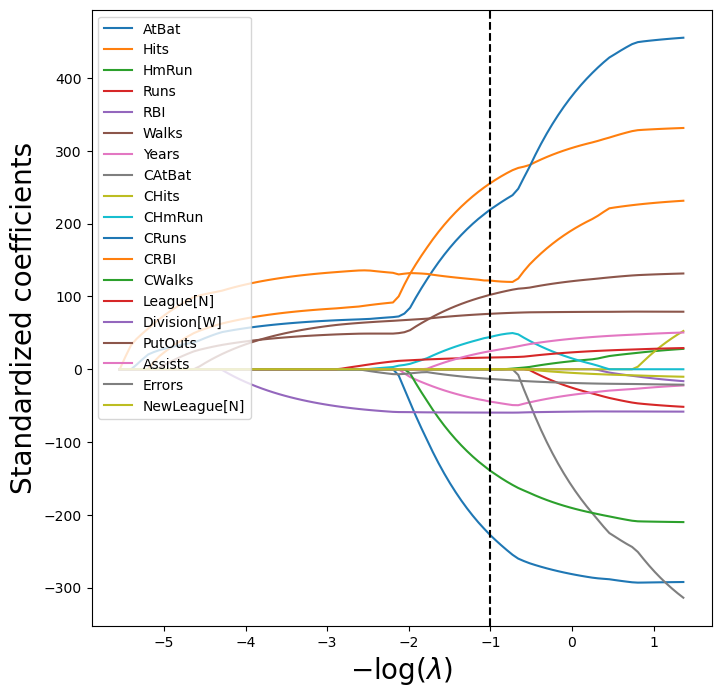

In [208]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.legend(loc='upper left')
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20);
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')

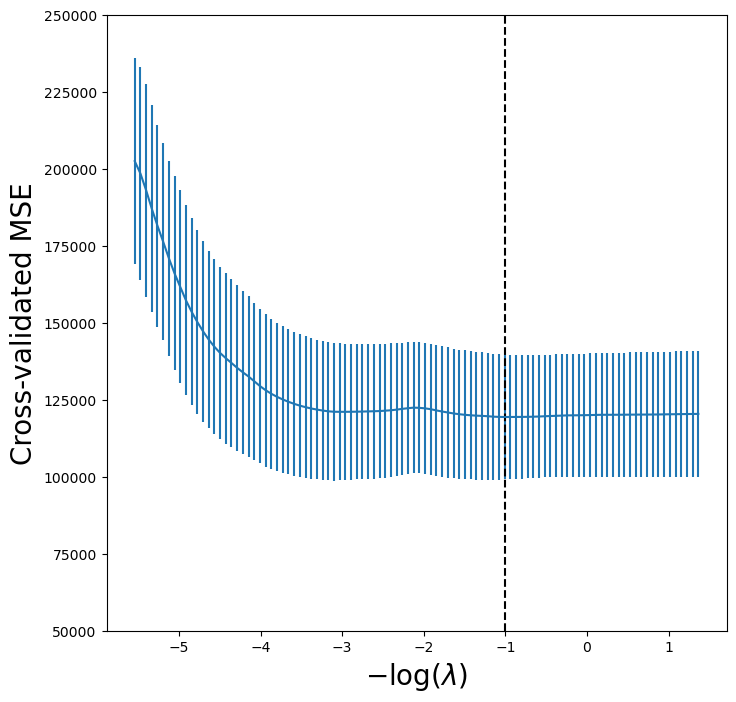

In [209]:
lassoCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_ylim([50000,250000])
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

We can compare to ridge regression:

In [210]:
lambdas = 10**np.linspace(8, -2, 100) / Y.std()

ridgeCV = skl.ElasticNetCV(alphas=lambdas, # need to provide for ridge
                           l1_ratio=0, # l1_ratio=0 for ridge!
                           cv=K)
pipeCV = Pipeline(steps=[('scaler', scaler),
                         ('ridge', ridgeCV)])
pipeCV.fit(X, Y)
tuned_ridge = pipeCV.named_steps['ridge']

In [213]:
tuned_ridge.coef_

array([-222.80877051,  238.77246614,    3.21103754,   -2.93050845,
          3.64888723,  108.90953869,  -50.81896152, -105.15731984,
        122.00714801,   57.1859509 ,  210.35170348,  118.05683748,
       -150.21959435,   30.36634231,  -61.62459095,   77.73832472,
         40.07350744,  -25.02151514,  -13.68429544])

We can see the coefficients are not exactly zero.

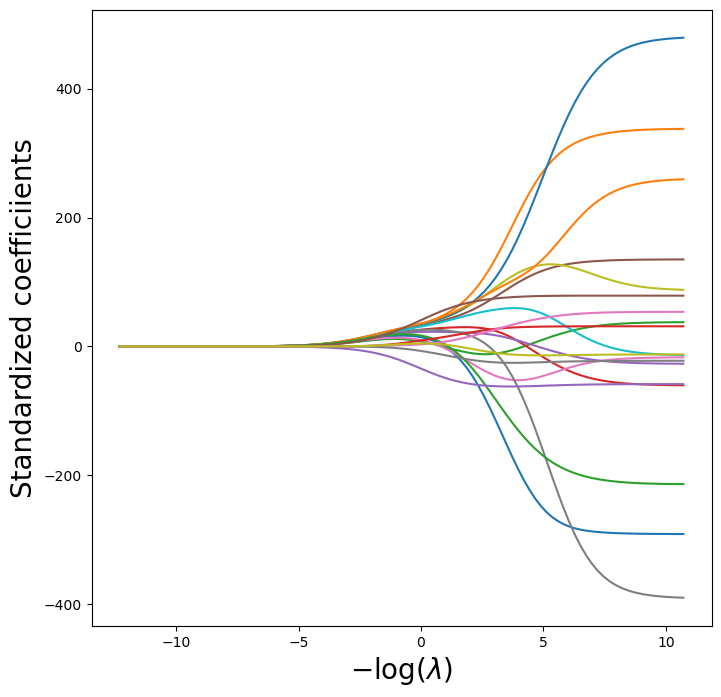

In [211]:
lambdas, soln_array = skl.ElasticNet.path(Xs, Y, l1_ratio=0, alphas=lambdas)[:2]
soln_path = pd.DataFrame(soln_array.T,columns=dat.columns, index=-np.log(lambdas))

path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficiients', fontsize=20);

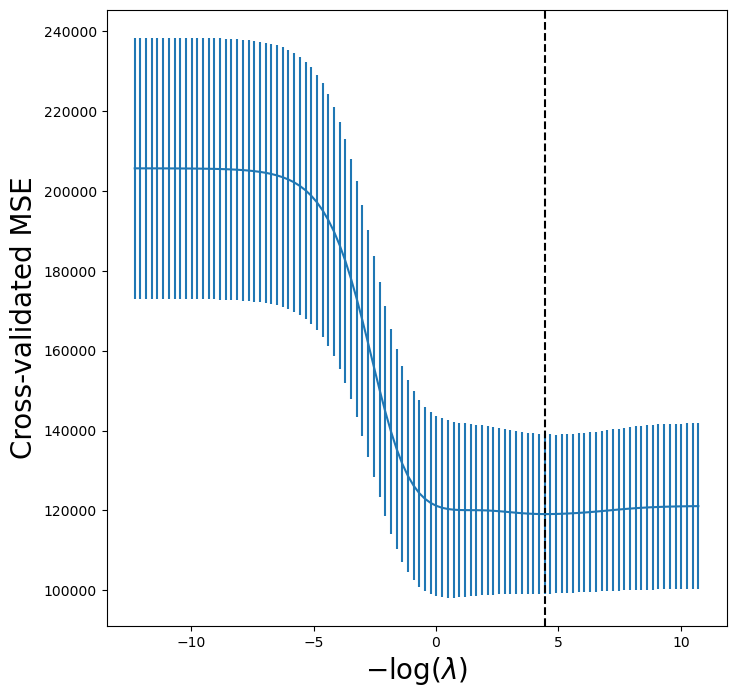

In [212]:
tuned_ridge = pipeCV.named_steps['ridge']
ridgeCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas),
            tuned_ridge.mse_path_.mean(1),
            yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_ridge.alpha_), c='k', ls='--')
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);